In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import argparse
import numpy as np
import pandas as pd 
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
# from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt


notebook_dir = os.getcwd()
target_path = os.path.abspath(os.path.join(notebook_dir, '../Python_Code'))
sys.path.append(target_path)
from dataGenerator import DataGeneratorUnified, DataGenerator

import util

# Constants
num_classes = 20
window_size = 50
epoch = 15

nr_subcarriers = NoOfSubcarrier = 242
window_size = 50
labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']

2025-06-07 17:06:20.663096: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-07 17:06:20.674583: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-07 17:06:20.678037: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-07 17:06:20.688302: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-07 17:06:21.642323: W tensorflow/compiler/tf2

In [5]:
def create_datagenerator(train_environments=['Classroom', 'Office'], train_monitors=['m1', 'm2', 'm3'],):
  train_list_dataset_paths = []
  train_list_dataset_csvs = []
  val_list_dataset_paths = []
  val_list_dataset_csvs = []
  test_list_dataset_paths = []
  test_list_dataset_csvs = []


  for train_environment in train_environments:
    for train_monitor in train_monitors:
      train_dir = f'../Data/fine_grained/{train_environment}/80MHz/3mo/{train_monitor}/Slots/Train'
      test_dir = f'../Data/fine_grained/{train_environment}/80MHz/3mo/{train_monitor}/Slots/Test'
      train_csv = os.path.join(train_dir, 'train_set.csv')
      val_csv = os.path.join(train_dir, 'val_set.csv')
      test_csv = os.path.join(test_dir, 'test_set.csv')

      train_list_dataset_paths.append(train_dir)
      train_list_dataset_csvs.append(train_csv)
      val_list_dataset_paths.append(train_dir)
      val_list_dataset_csvs.append(val_csv)
      test_list_dataset_paths.append(test_dir)
      test_list_dataset_csvs.append(test_csv)


  nr_subcarriers = 242
  window_size = 50
  labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']

  train_gen = DataGeneratorUnified(train_list_dataset_paths, train_list_dataset_csvs, nr_subcarriers, len(labels), (window_size, nr_subcarriers, 2), batchsize=64, shuffle=True)
  val_gen = DataGeneratorUnified(val_list_dataset_paths, val_list_dataset_csvs, nr_subcarriers, len(labels), (window_size, nr_subcarriers, 2), batchsize=64, shuffle=True)
  test_gen = DataGeneratorUnified(test_list_dataset_paths, test_list_dataset_csvs, nr_subcarriers, len(labels), (window_size, nr_subcarriers, 2), batchsize=64, shuffle=False)

  return train_gen, val_gen, test_gen

# Model Definition
def get_baseline_model(slice_size, classes, NoOfSubcarrier, fc1, fc2):
    model = models.Sequential()

    model.add(layers.Input(shape=(slice_size, NoOfSubcarrier, 2), name='input_layer'))

    model.add(layers.Conv2D(64, (3, 3), padding='same', strides=2, input_shape=(slice_size, NoOfSubcarrier, 2), name='conv2d'))
    model.add(layers.BatchNormalization(name='batch_normalization'))
    model.add(layers.ReLU(name='re_lu'))

    model.add(layers.Conv2D(64, (3, 3), padding='same', name='conv2d_1'))
    model.add(layers.BatchNormalization(name='batch_normalization_1'))
    model.add(layers.ReLU(name='re_lu_1'))

    model.add(layers.Activation('relu', name='activation'))

    model.add(layers.Conv2D(64, (3, 3), padding='same', name='conv2d_2'))
    model.add(layers.BatchNormalization(name='batch_normalization_2'))
    model.add(layers.ReLU(name='re_lu_2'))

    model.add(layers.Conv2D(64, (3, 3), padding='same', name='conv2d_3'))
    model.add(layers.BatchNormalization(name='batch_normalization_3'))
    model.add(layers.ReLU(name='re_lu_3'))

    model.add(layers.MaxPooling2D(pool_size=(2, 1), name='max_pooling2d'))
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(classes, activation='softmax', name='dense'))

    model.summary()

    return model

def train_model(model, train_gen, val_gen, model_dir):
  learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', patience=15, verbose=1, factor=0.5, min_lr=0.0001)
  checkpoint = ModelCheckpoint(model_dir, verbose=1, save_best_only=True)
  earlystopping = EarlyStopping(monitor='val_loss', min_delta=0.05, patience=10, verbose=1)

  history = model.fit(
      x=train_gen,
      epochs=epoch,
      validation_data=val_gen,
      callbacks=[learning_rate_reduction, checkpoint, earlystopping],
      verbose=1
  )

  return history

def plot_accuracy(history, output_filename=None):
    import matplotlib.pyplot as plt

    plt.plot(history.history["accuracy"], label="Training acc")
    plt.plot(history.history["val_accuracy"], label="Validation acc")
    plt.legend()
    if output_filename:
      plt.savefig(output_filename, dpi=300)
    
    plt.show()

# Plotting Accuracy

Training on environment: Classroom


/home/diogo/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 121, 64)    │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 25, 121, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 121, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 121, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 121, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 121, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 121, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 121, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 92928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │     1,858,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,971,604 (7.52 MB)

...

2227/2227 ━━━━━━━━━━━━━━━━━━━━ 98s 44ms/step - accuracy: 0.9701 - loss: 0.1036 - val_accuracy: 0.9722 - val_loss: 0.0930 - learning_rate: 0.0100
Epoch 4/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9762 - loss: 0.0788
Epoch 4: val_loss improved from 0.09301 to 0.06666, saving model to ../trained_models/fine_grained_trainedon_Classroom_m1m2m3_242.h5


2227/2227 ━━━━━━━━━━━━━━━━━━━━ 99s 44ms/step - accuracy: 0.9762 - loss: 0.0788 - val_accuracy: 0.9826 - val_loss: 0.0667 - learning_rate: 0.0100
Epoch 5/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9823 - loss: 0.0589
Epoch 5: val_loss did not improve from 0.06666
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.9823 - loss: 0.0589 - val_accuracy: 0.9792 - val_loss: 0.0847 - learning_rate: 0.0100
Epoch 6/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9848 - loss: 0.0519
Epoch 6: val_loss improved from 0.06666 to 0.05136, saving model to ../trained_models/fine_grained_trainedon_Classroom_m1m2m3_242.h5


2227/2227 ━━━━━━━━━━━━━━━━━━━━ 84s 38ms/step - accuracy: 0.9848 - loss: 0.0519 - val_accuracy: 0.9874 - val_loss: 0.0514 - learning_rate: 0.0100
Epoch 7/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9873 - loss: 0.0434
Epoch 7: val_loss did not improve from 0.05136
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.9873 - loss: 0.0434 - val_accuracy: 0.9873 - val_loss: 0.0530 - learning_rate: 0.0100
Epoch 8/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9893 - loss: 0.0370
Epoch 8: val_loss improved from 0.05136 to 0.04288, saving model to ../trained_models/fine_grained_trainedon_Classroom_m1m2m3_242.h5


2227/2227 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.9893 - loss: 0.0370 - val_accuracy: 0.9910 - val_loss: 0.0429 - learning_rate: 0.0100
Epoch 9/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9908 - loss: 0.0328
Epoch 9: val_loss did not improve from 0.04288
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.9908 - loss: 0.0328 - val_accuracy: 0.9860 - val_loss: 0.0657 - learning_rate: 0.0100
Epoch 10/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9909 - loss: 0.0318
Epoch 10: val_loss did not improve from 0.04288
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 81s 36ms/step - accuracy: 0.9909 - loss: 0.0318 - val_accuracy: 0.9859 - val_loss: 0.0665 - learning_rate: 0.0100
Epoch 11/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9902 - loss: 0.0338
Epoch 11: val_loss did not improve from 0.04288
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 80s 36ms/step - accuracy: 0.9902 - loss: 0.0338 - val_accuracy: 0.9887 - val_loss: 0.0598 - learning_rate: 0.0100
Epoch 12

2227/2227 ━━━━━━━━━━━━━━━━━━━━ 86s 38ms/step - accuracy: 0.9924 - loss: 0.0293 - val_accuracy: 0.9920 - val_loss: 0.0370 - learning_rate: 0.0100
Epoch 13/15
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9926 - loss: 0.0275
Epoch 13: val_loss did not improve from 0.03702
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9926 - loss: 0.0275 - val_accuracy: 0.9919 - val_loss: 0.0434 - learning_rate: 0.0100
Epoch 14/15
2226/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9942 - loss: 0.0215
Epoch 14: val_loss did not improve from 0.03702
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.9942 - loss: 0.0215 - val_accuracy: 0.9899 - val_loss: 0.0592 - learning_rate: 0.0100
Epoch 15/15
2226/2227 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9931 - loss: 0.0271
Epoch 15: val_loss did not improve from 0.03702
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 79s 36ms/step - accuracy: 0.9931 - loss: 0.0271 - val_accuracy: 0.9920 - val_loss: 0.0476 - learning_rate: 0.0100


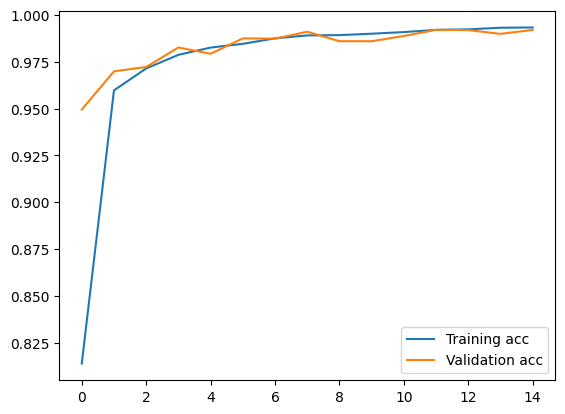

The validation accuracy is : [0.9494650959968567, 0.9698479771614075, 0.9721846580505371, 0.9826013445854187, 0.9792229533195496, 0.9874436855316162, 0.9873310923576355, 0.9909909963607788, 0.9859516024589539, 0.9859234094619751, 0.9887387156486511, 0.9920045137405396, 0.9918637275695801, 0.9898648858070374, 0.9919763803482056]
The training accuracy is : [0.8139312863349915, 0.9597131609916687, 0.971402108669281, 0.9786638617515564, 0.9825437664985657, 0.9845433831214905, 0.9874691367149353, 0.9890267252922058, 0.9891880750656128, 0.9899458289146423, 0.9908158183097839, 0.9919875264167786, 0.9922822117805481, 0.993131160736084, 0.9932714700698853]
The validation loss is : [0.16968271136283875, 0.10260271281003952, 0.09301172941923141, 0.06665683537721634, 0.08471696823835373, 0.05136328935623169, 0.053031075745821, 0.042879607528448105, 0.06574422121047974, 0.06649906188249588, 0.05982504412531853, 0.03702213615179062, 0.043377190828323364, 0.05916877090930939, 0.04761591553688049]
The

/home/diogo/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 121, 64)    │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 25, 121, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 121, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 121, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 121, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 121, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 121, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 121, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 25, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 121, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 92928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │     1,858,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,971,604 (7.52 MB)

...

3487/3487 ━━━━━━━━━━━━━━━━━━━━ 193s 55ms/step - accuracy: 0.9445 - loss: 0.1757 - val_accuracy: 0.9695 - val_loss: 0.0949 - learning_rate: 0.0100
Epoch 3/15
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9649 - loss: 0.1080
Epoch 3: val_loss improved from 0.09491 to 0.08946, saving model to ../trained_models/fine_grained_trainedon_Office_m1m2m3_242.h5


3487/3487 ━━━━━━━━━━━━━━━━━━━━ 198s 57ms/step - accuracy: 0.9649 - loss: 0.1080 - val_accuracy: 0.9703 - val_loss: 0.0895 - learning_rate: 0.0100
Epoch 4/15
3486/3487 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9732 - loss: 0.0812
Epoch 4: val_loss improved from 0.08946 to 0.06960, saving model to ../trained_models/fine_grained_trainedon_Office_m1m2m3_242.h5


3487/3487 ━━━━━━━━━━━━━━━━━━━━ 193s 55ms/step - accuracy: 0.9732 - loss: 0.0812 - val_accuracy: 0.9784 - val_loss: 0.0696 - learning_rate: 0.0100
Epoch 5/15
3486/3487 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9774 - loss: 0.0690
Epoch 5: val_loss improved from 0.06960 to 0.05859, saving model to ../trained_models/fine_grained_trainedon_Office_m1m2m3_242.h5


3487/3487 ━━━━━━━━━━━━━━━━━━━━ 197s 56ms/step - accuracy: 0.9774 - loss: 0.0690 - val_accuracy: 0.9817 - val_loss: 0.0586 - learning_rate: 0.0100
Epoch 6/15
3486/3487 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9814 - loss: 0.0568
Epoch 6: val_loss improved from 0.05859 to 0.04363, saving model to ../trained_models/fine_grained_trainedon_Office_m1m2m3_242.h5


3487/3487 ━━━━━━━━━━━━━━━━━━━━ 192s 55ms/step - accuracy: 0.9814 - loss: 0.0568 - val_accuracy: 0.9865 - val_loss: 0.0436 - learning_rate: 0.0100
Epoch 7/15
3486/3487 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9833 - loss: 0.0509
Epoch 7: val_loss did not improve from 0.04363
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 181s 52ms/step - accuracy: 0.9833 - loss: 0.0509 - val_accuracy: 0.9844 - val_loss: 0.0510 - learning_rate: 0.0100
Epoch 8/15
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9856 - loss: 0.0443
Epoch 8: val_loss did not improve from 0.04363
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 189s 54ms/step - accuracy: 0.9856 - loss: 0.0443 - val_accuracy: 0.9810 - val_loss: 0.0692 - learning_rate: 0.0100
Epoch 9/15
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9866 - loss: 0.0416
Epoch 9: val_loss did not improve from 0.04363
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 187s 54ms/step - accuracy: 0.9866 - loss: 0.0416 - val_accuracy: 0.9833 - val_loss: 0.0550 - learning_rate: 0.0100
Epoch 10

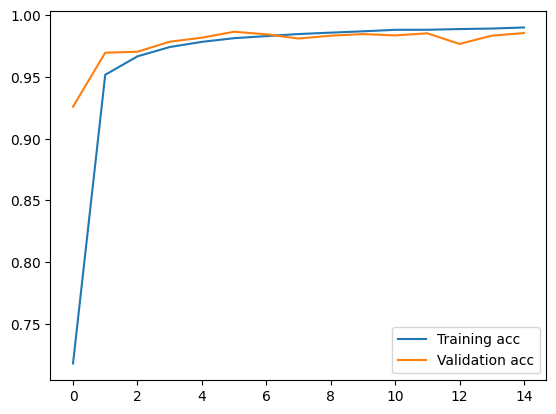

The validation accuracy is : [0.9258307218551636, 0.9695231318473816, 0.9703322649002075, 0.9784054756164551, 0.9816779494285583, 0.9864786863327026, 0.9844289422035217, 0.980994701385498, 0.9833321571350098, 0.9846087694168091, 0.9835119247436523, 0.9852200746536255, 0.9766254425048828, 0.9833141565322876, 0.9854178428649902]
The training accuracy is : [0.7181361317634583, 0.9516597390174866, 0.9665722846984863, 0.9740957617759705, 0.9783033132553101, 0.9812831878662109, 0.9829545617103577, 0.9846304059028625, 0.9857640862464905, 0.986844003200531, 0.9880448579788208, 0.9880717396736145, 0.9886587858200073, 0.9890710115432739, 0.9899402856826782]
The validation loss is : [0.2295534908771515, 0.09491104632616043, 0.08946076780557632, 0.06959628313779831, 0.05858845263719559, 0.043626632541418076, 0.051034193485975266, 0.06919300556182861, 0.05495046451687813, 0.05218749865889549, 0.05217122286558151, 0.04530515894293785, 0.09104452282190323, 0.06388108432292938, 0.0539020374417305]
The

In [7]:
environments_to_train = ['Classroom', 'Office']

for environment_to_train in environments_to_train:
  print(f"Training on environment: {environment_to_train}")
  train_gen, val_gen, test_gen  = create_datagenerator(train_environments=[environment_to_train])

  # Model Definition
  model = get_baseline_model(window_size, len(labels), NoOfSubcarrier, fc1=256, fc2=128)

  # Compiling the Model
  model.compile(optimizer=keras.optimizers.Adam(0.01), loss="categorical_crossentropy", metrics=["accuracy"])

  # Training the Model
  model_dir = f'../trained_models/fine_grained_trainedon_{environment_to_train}_m1m2m3_242.h5'
  history = train_model(model, train_gen, val_gen, model_dir)

  plot_accuracy(history, 'SAIDAS/18-fine_grained_trainedon_{environment_to_train}_m1m2m3_242_train_accuracy.png')

  # Evaluating Model
  print("The validation accuracy is :", history.history['val_accuracy'])
  print("The training accuracy is :", history.history['accuracy'])
  print("The validation loss is :", history.history['val_loss'])
  print("The training loss is :", history.history['loss'])
  print()


----
# Evaluation

In [9]:
def evaluate_subject_with_data_from(model, test_environment, test_monitor, nr_subcarriers=242):
  test_dir = f'../Data/fine_grained/{test_environment}/80MHz/3mo/{test_monitor}/Slots/Test'
  test_csv = os.path.join(test_dir, 'test_set.csv')
  window_size = 50
  labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T']

  test_gen = DataGenerator(test_dir, test_csv, nr_subcarriers, len(labels), (window_size, nr_subcarriers, 2), batchsize=64, shuffle=False)

  final_loss, final_accuracy = model.evaluate(test_gen)
  return final_loss, final_accuracy

In [11]:
train_enviroments = ['Classroom', 'Office']
test_environments  = ['Classroom', 'Office']
test_monitors  = ['m1', 'm2', 'm3']

results = {
  'train_environments': [],
  'train_monitors': [],
  'test_environments': [],
  'test_monitors': [], 
  'final_loss': [], 
  'final_accuracy': []
}

for train_enviroment in train_enviroments:
  model_path  = f'../trained_models/fine_grained_trainedon_{train_enviroment}_m1m2m3_242.h5'
  model = load_model(model_path)

  for test_environment in test_environments:
    for test_monitor in test_monitors:
      print(f"Evaluating model trained on all monitors of Enviroment: {train_enviroment} against {test_environment} with monitor {test_monitor}")
      final_loss, final_accuracy = evaluate_subject_with_data_from(model, test_environment, test_monitor)
      results['train_environments'].append(train_enviroment)
      results['train_monitors'].append('m1m2m3')
      results['test_environments'].append(test_environment)
      results['test_monitors'].append(test_monitor)
      results['final_loss'].append(final_loss)
      results['final_accuracy'].append(final_accuracy)
# Convert results to DataFrame
results_df = pd.DataFrame(results)
# Save results to CSV
results_df.to_csv('SAIDAS/18-results_fine_grained_multimonitor_single_environment.csv', index=False)




/home/diogo/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Evaluating model trained on all monitors of Enviroment: Classroom against Classroom with monitor m1
308/308 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9814 - loss: 0.1059
Evaluating model trained on all monitors of Enviroment: Classroom against Classroom with monitor m2
  1/295 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 1.0000 - loss: 6.5765e-05

/home/diogo/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.9614 - loss: 0.1688
Evaluating model trained on all monitors of Enviroment: Classroom against Classroom with monitor m3
  3/305 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9783 - loss: 0.0469

/home/diogo/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


...

479/479 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9705 - loss: 0.1184
Evaluating model trained on all monitors of Enviroment: Office against Office with monitor m2
  1/488 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9688 - loss: 0.1408

/home/diogo/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


488/488 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.9135 - loss: 0.3175
Evaluating model trained on all monitors of Enviroment: Office against Office with monitor m3
  1/458 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 1.0000 - loss: 0.0179

/home/diogo/miniconda3/envs/tensorflow/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


458/458 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9663 - loss: 0.1061


----
# Creating plots


In [20]:
single_monitor_single_environment = pd.read_csv('SAIDAS/01-results_fine_grained.csv')
multi_monitor_multi_environment = pd.read_csv('SAIDAS/07-results_fine_grained_multimonitor_multienvironment.csv')
multi_monitor_single_environment = pd.read_csv('SAIDAS/18-results_fine_grained_multimonitor_single_environment.csv')

multi_monitor_multi_environment['train_environments'] = 'ClassroomOffice'
multi_monitor_multi_environment['train_monitors'] = 'm1m2m3'
multi_monitor_multi_environment = multi_monitor_multi_environment[['train_environments', 'train_monitors', 'test_environments', 'test_monitors', 'final_loss', 'final_accuracy'  ]]

In [24]:
accuracy = pd.concat([single_monitor_single_environment, multi_monitor_single_environment, multi_monitor_multi_environment], ignore_index=True)
accuracy.to_csv('SAIDAS/18-summary_accuracy_across_monitors_and_envirments.csv', index=False)

/tmp/ipykernel_2415787/2991276491.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[row_index, col_index].legend()


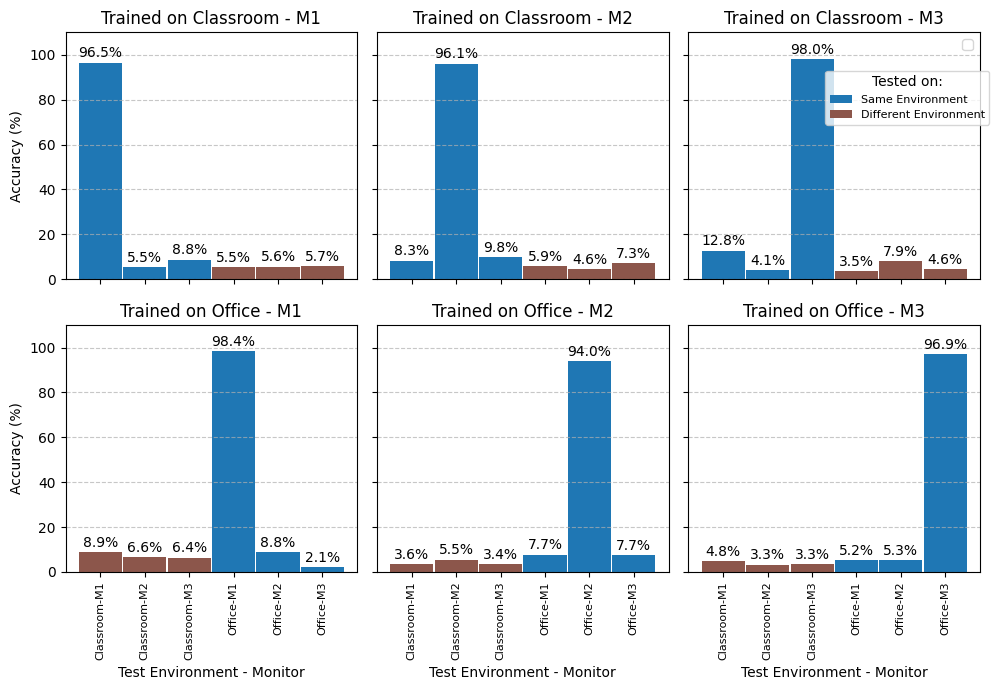

In [40]:
def plot1(df):
    # Configurações
    train_environments = ['Classroom', 'Office']
    train_monitors = ['m1', 'm2', 'm3']
    test_environments = ['Classroom', 'Office']
    test_monitors = ['m1', 'm2', 'm3']
    colors = {'Same Environment': '#1f77b4', 'Different Environment': '#8c564b'}

    bar_width = 0.5
    x = np.arange(len(train_monitors))  
    rows = len(train_environments)
    cols = len(train_monitors)

    fig, axs = plt.subplots(rows, cols, figsize=(10, 3.5*rows), sharex=True, sharey=True)

    added_labels = set()
    xticks = []
    xtick_labels = ['Classroom-M1', 'Classroom-M2', 'Classroom-M3', 'Office-M1', 'Office-M2', 'Office-M3'] 

    for row_index in range(rows):
      for col_index in range(cols):
        train_environment = train_environments[row_index]
        train_monitor = train_monitors[col_index]
        axs[row_index, col_index].set_title(f'Trained on {train_environments[row_index]} - {train_monitors[col_index].upper()}')
        if col_index == 0:
          axs[row_index, col_index].set_ylabel('Accuracy (%)')
        if col_index == cols - 1 and row_index == 0:
          axs[row_index, col_index].legend()
        axs[row_index, col_index].grid(axis='y', linestyle='--', alpha=0.7)
        for test_environment_index in range(len(test_environments)):
          for test_monitor_index in range(len(test_monitors)):
            test_environment = test_environments[test_environment_index]
            test_monitor = test_monitors[test_monitor_index]
            env_type = 'Same Environment' if train_environment == test_environment else 'Different Environment'
            

            if row_index == 1:
              axs[row_index, col_index].set_xlabel('Test Environment - Monitor', fontsize=10)
            axs[row_index, col_index].set_ylim(0, 110)

            accuracy = df[
                        (df['train_environments'] == train_environment)
                        & (df['train_monitors'] == train_monitor) 
                        & (df['test_environments'] == test_environment)
                        & (df['test_monitors'] == test_monitor)
                    ]['final_accuracy'].item() * 100
            
            label = env_type if env_type not in added_labels else None
            if label:
                added_labels.add(env_type)

            color = colors[env_type]
            x_pos = test_monitor_index * bar_width + 3 * test_environment_index * bar_width
            xticks.append(x_pos)
            bars = axs[row_index, col_index].bar(x_pos, accuracy, width=bar_width*0.97, label=label, color=color)
            for bar in bars:
              height = bar.get_height()
              axs[row_index, col_index].text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
        axs[row_index, col_index].set_xticks(xticks)
        axs[row_index, col_index].set_xticklabels(xtick_labels, fontsize=8, rotation=90)
        xticks = []

    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right',  bbox_to_anchor=(1, 0.9), fontsize=8, title='Tested on:')
    plt.tight_layout()
    plt.savefig('SAIDAS/18-results_single_monitor_single_enviroment.png', dpi=300, bbox_inches='tight')
    plt.show()

plot1(accuracy)

/tmp/ipykernel_2415787/936210810.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[row_index, col_index].legend()


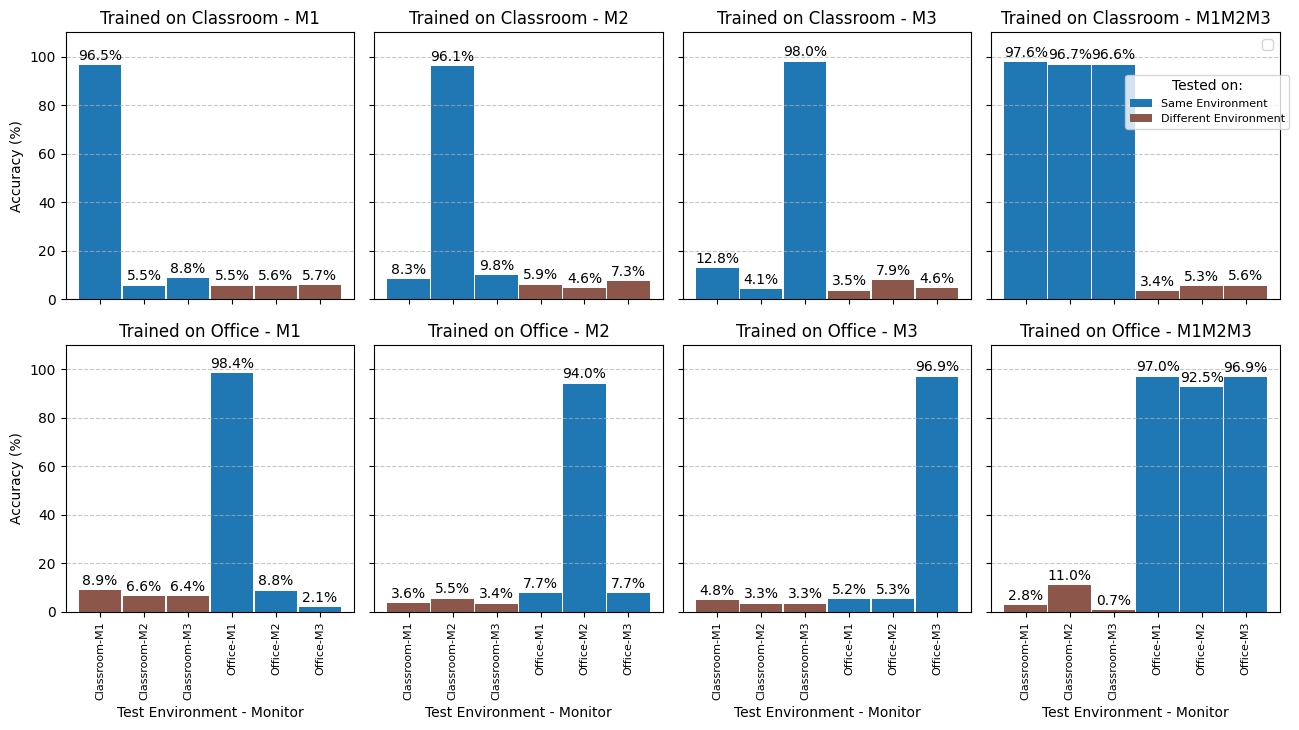

In [60]:
def plot2(df):
    # Configurações
    train_environments = ['Classroom', 'Office']
    train_monitors = ['m1', 'm2', 'm3', 'm1m2m3']
    test_environments = ['Classroom', 'Office']
    test_monitors = ['m1', 'm2', 'm3']
    colors = {'Same Environment': '#1f77b4', 'Different Environment': '#8c564b'}

    bar_width = 0.5
    x = np.arange(len(train_monitors))  
    rows = len(train_environments)
    cols = len(train_monitors)

    fig, axs = plt.subplots(rows, cols, figsize=(13, 3.7*rows), sharex=True, sharey=True)

    added_labels = set()
    xticks = []
    xtick_labels = ['Classroom-M1', 'Classroom-M2', 'Classroom-M3', 'Office-M1', 'Office-M2', 'Office-M3'] 

    for row_index in range(rows):
      for col_index in range(cols):
        train_environment = train_environments[row_index]
        train_monitor = train_monitors[col_index]
        axs[row_index, col_index].set_title(f'Trained on {train_environments[row_index]} - {train_monitors[col_index].upper()}')
        if col_index == 0:
          axs[row_index, col_index].set_ylabel('Accuracy (%)')
        if col_index == cols - 1 and row_index == 0:
          axs[row_index, col_index].legend()
        axs[row_index, col_index].grid(axis='y', linestyle='--', alpha=0.7)
        for test_environment_index in range(len(test_environments)):
          for test_monitor_index in range(len(test_monitors)):
            test_environment = test_environments[test_environment_index]
            test_monitor = test_monitors[test_monitor_index]
            env_type = 'Same Environment' if train_environment == test_environment else 'Different Environment'
            if row_index == 1:
              axs[row_index, col_index].set_xlabel('Test Environment - Monitor', fontsize=10)
            axs[row_index, col_index].set_ylim(0, 110)
            accuracy = df[
                        (df['train_environments'] == train_environment)
                        & (df['train_monitors'] == train_monitor) 
                        & (df['test_environments'] == test_environment)
                        & (df['test_monitors'] == test_monitor)
                    ]['final_accuracy'].item() * 100
            
            label = env_type if env_type not in added_labels else None
            if label:
                added_labels.add(env_type)

            color = colors[env_type]
            x_pos = test_monitor_index * bar_width + 3 * test_environment_index * bar_width
            xticks.append(x_pos)
            bars = axs[row_index, col_index].bar(x_pos, accuracy, width=bar_width*0.97, label=label, color=color)
            for bar in bars:
              height = bar.get_height()
              axs[row_index, col_index].text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
        axs[row_index, col_index].set_xticks(xticks)
        axs[row_index, col_index].set_xticklabels(xtick_labels, fontsize=8, rotation=90)
        xticks = []

    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right',  bbox_to_anchor=(1, 0.9), fontsize=8, title='Tested on:')

    plt.tight_layout()
    plt.savefig('SAIDAS/18-results_single_monitor_single_enviroment_v2.png', dpi=300, bbox_inches='tight')
    plt.show()

plot2(accuracy)

/tmp/ipykernel_2415787/2681262179.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[row_index, col_index].legend()


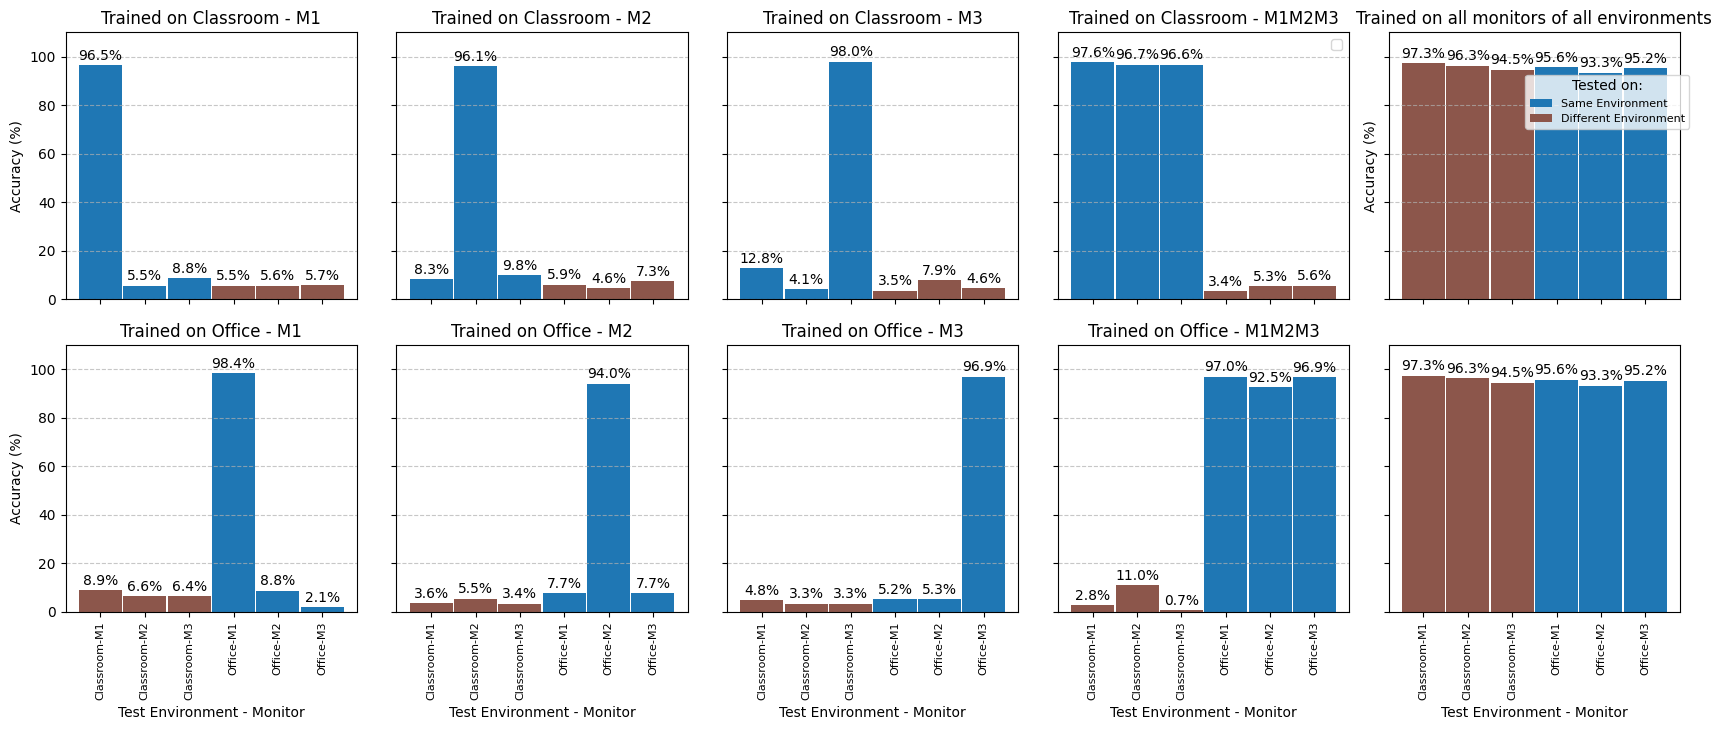

In [59]:
def plot3(df):
    # Configurações
    train_environments = ['Classroom', 'Office']
    train_monitors = ['m1', 'm2', 'm3', 'm1m2m3']
    test_environments = ['Classroom', 'Office']
    test_monitors = ['m1', 'm2', 'm3']
    colors = {'Same Environment': '#1f77b4', 'Different Environment': '#8c564b'}

    bar_width = 0.5
    x = np.arange(len(train_monitors))  
    rows = len(train_environments)
    cols = len(train_monitors)

    fig, axs = plt.subplots(rows, cols+1, figsize=(17, 3.7*rows), sharex=True, sharey=True)

    added_labels = set()
    xticks = []
    xtick_labels = ['Classroom-M1', 'Classroom-M2', 'Classroom-M3', 'Office-M1', 'Office-M2', 'Office-M3'] 

    for row_index in range(rows):
      for col_index in range(cols):
        train_environment = train_environments[row_index]
        train_monitor = train_monitors[col_index]
        axs[row_index, col_index].set_title(f'Trained on {train_environments[row_index]} - {train_monitors[col_index].upper()}')
        if col_index == 0:
          axs[row_index, col_index].set_ylabel('Accuracy (%)')
        if col_index == cols - 1 and row_index == 0:
          axs[row_index, col_index].legend()
        axs[row_index, col_index].grid(axis='y', linestyle='--', alpha=0.7)
        for test_environment_index in range(len(test_environments)):
          for test_monitor_index in range(len(test_monitors)):
            test_environment = test_environments[test_environment_index]
            test_monitor = test_monitors[test_monitor_index]
            env_type = 'Same Environment' if train_environment == test_environment else 'Different Environment'
            if row_index == 1:
              axs[row_index, col_index].set_xlabel('Test Environment - Monitor', fontsize=10)
            axs[row_index, col_index].set_ylim(0, 110)
            accuracy = df[
                        (df['train_environments'] == train_environment)
                        & (df['train_monitors'] == train_monitor) 
                        & (df['test_environments'] == test_environment)
                        & (df['test_monitors'] == test_monitor)
                    ]['final_accuracy'].item() * 100
            
            label = env_type if env_type not in added_labels else None
            if label:
                added_labels.add(env_type)

            color = colors[env_type]
            x_pos = test_monitor_index * bar_width + 3 * test_environment_index * bar_width
            xticks.append(x_pos)
            bars = axs[row_index, col_index].bar(x_pos, accuracy, width=bar_width*0.97, label=label, color=color)
            for bar in bars:
              height = bar.get_height()
              axs[row_index, col_index].text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
        axs[row_index, col_index].set_xticks(xticks)
        axs[row_index, col_index].set_xticklabels(xtick_labels, fontsize=8, rotation=90)
        xticks = []

    # Accuracy for all monitors trained on all environments
    axs[0, cols].set_title('Trained on all monitors of all environments')
    axs[0, cols].set_ylabel('Accuracy (%)')
    axs[0, cols].grid(axis='y', linestyle='--', alpha=0.7)
    axs[1, cols].set_xlabel('Test Environment - Monitor', fontsize=10)
    axs[0, cols].set_ylim(0, 110)
    for test_environment_index in range(len(test_environments)):
      for test_monitor_index in range(len(test_monitors)):
        test_environment = test_environments[test_environment_index]
        test_monitor = test_monitors[test_monitor_index]
        env_type = 'Same Environment' if train_environment == test_environment else 'Different Environment'
        accuracy = df[
                    (df['train_environments'] == 'ClassroomOffice')
                    & (df['train_monitors'] == 'm1m2m3') 
                    & (df['test_environments'] == test_environment)
                    & (df['test_monitors'] == test_monitor)
                ]['final_accuracy'].item() * 100
        
        label = env_type if env_type not in added_labels else None
        if label:
            added_labels.add(env_type)

        color = colors[env_type]
        x_pos = test_monitor_index * bar_width + 3 * test_environment_index * bar_width
        xticks.append(x_pos)
        bars = axs[0, cols].bar(x_pos, accuracy, width=bar_width*0.97, label=label, color=color)
        for bar in bars:
          height = bar.get_height()
          axs[0, cols].text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
        
        bars = axs[1, cols].bar(x_pos, accuracy, width=bar_width*0.97, label=label, color=color)
        for bar in bars:
          height = bar.get_height()
          axs[1, cols].text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

    axs[1, cols].set_xticks(xticks)
    axs[1, cols].set_xticklabels(xtick_labels, fontsize=8, rotation=90)
    xticks = []


    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right',  bbox_to_anchor=(1, 0.9), fontsize=8, title='Tested on:')

    plt.tight_layout()
    plt.savefig('SAIDAS/18-results_single_monitor_single_enviroment_v3.png', dpi=300, bbox_inches='tight')
    plt.show()

plot3(accuracy)

In [44]:
accuracy

,train_environments,train_monitors,test_environments,test_monitors,final_loss,final_accuracy
0,Classroom,m1,Classroom,m1,0.141291,0.965351
1,Classroom,m1,Classroom,m2,11.805790,0.055191
2,Classroom,m1,Classroom,m3,11.811633,0.087602
3,Classroom,m1,Office,m1,14.996040,0.055095
4,Classroom,m1,Office,m2,18.573046,0.056224
5,Classroom,m1,Office,m3,12.357594,0.057451
6,Classroom,m2,Classroom,m1,40.302887,0.082894
7,Classroom,m2,Classroom,m2,0.123919,0.960593
8,Classroom,m2,Classroom,m3,32.196171,0.098053
9,Classroom,m2,Office,m1,37.394539,0.059303
